# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [34]:
# ! pip install pandas
# ! pip install numpy
# ! pip install matplotlib
# ! pip install seaborn
# import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

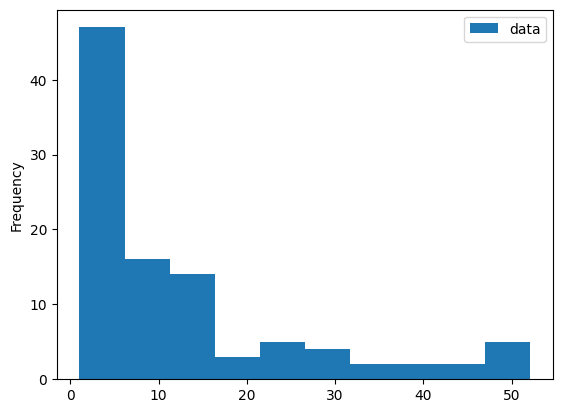

In [4]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

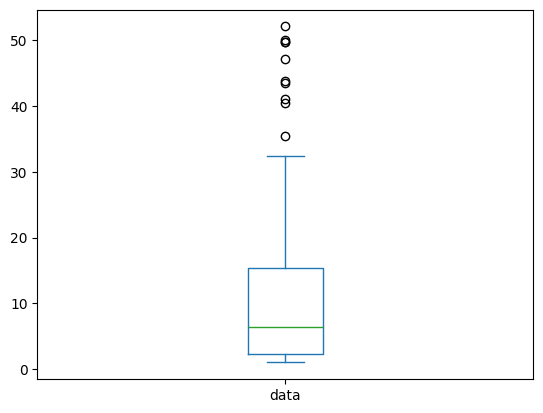

In [5]:
df.plot.box()

Problem:
Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

Histogram

Pros: Easy to get a glipse of the distribution of the data, in a relatively universal plot type.
Shows the right sided skew

Cons: Does not label the x-axis or the plot itself both of which are major drawbacks. 
No context as to whether these outliers are within the expected normal range or potential messy/incorrect data
The bins are very wide and seem to bleed into one another a bit, I would add in some white space between bins.



Box plot

Pros: Get a feel for the distribution of the data very quickly - shows a lot of good data like the median and 25-75% quartiles data.

Cons: Tend to be a bit more technical, so depending on your audience (is it just general office staff who don't know much about stats?). 
There are a decent amount of outliers - would need to look deeper at the data to understand if this is expected.
No y label or overall plot label. The x label isn't particularly helpful.

Which would I choose?

Given the two options, I think the box plot is better. While it does require a certain extent of technical knowledge, it provides a multitude of useful information. 
At a glance, you can easily see both where the majority of the data falls and the appearance of potential outliers.
While this plot could still use some improvements format wise, the histogram needs more work to make it as readable.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

Thoughts

Basic data info:
1. Wow, this is a big dataset! Using describe, it looks like the counts are pretty consistent across rows which is a pleasant surprise. Looking at the info, a lot of the data is also one binary - will need to try to hunt down the data dictionary. Some columns like BMI are not binary - per cdc, listed below underweight is 18.5 and severe obesity is 40+
2. Looking at the stats, most participants are: females between 55-64 years old with good self reported health (although the majority are overweight). May be some bias as there is a larger proportion of participants with some level of college education and income levels tend to fall on the higher end.


Plots:
1. BMI hist shows some very low and VERY high BMIs, potential outliers. Min: 12 Max: 98 - DEF outliers. STD 6.608694
2. Age hist shows a significant increase around category 7 (50-54). There are quite a few younger than 50 though. I don't see any mention if this dataset differentiates between diabetes type 1 or 2. If it includes both, that could explain many of the younger ages. Although, this is a diabetes risk factor survey, so it could still be appropriate to include a wide spread of ages.
3. Education hist is heavily left skewed - lots have been to high school, but vast majority have some college experience
4. Diabetes bar shows VAST majority (>200k do NOT have diabetes)

Combined Exploratory Analysis:
1. Unsurprisingly, when grouping by BMI and diabetes status those with diabetes on average are obese whereas those without diabetes on average are only overweight
2. I then wanted to compare physical activity between diabetic categories - both groups on average have reported physical activity within the past month, but those without diabetes on average reported higher levels of activity
3. Those with high BP OVERWHELMINLY have on average a higher incidence of diabetes - most compelling comparison I've seen so far
4. Higher average incidence of high cholesterol with those who have diabetes, not as strong a relationship as the high BP though

Resources:
1. https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data
2. https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html

Text(0, 0.5, 'Average Incidence of High BP per Diabetes Diagnosis')

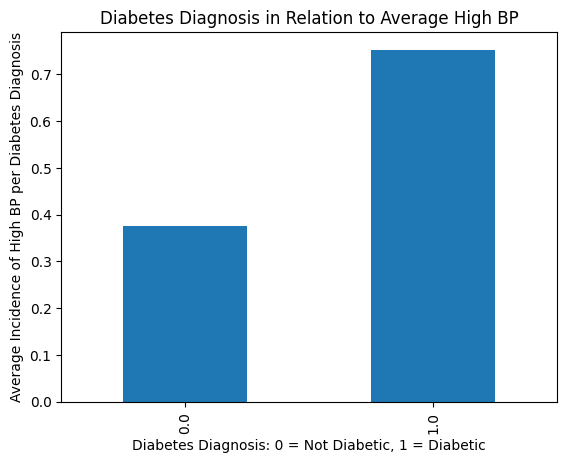

In [52]:
diabetes_df = pd.read_csv("diabetes_BRFSS2015.csv", sep=",")

diabetes_df.describe()
# diabetes_df.head(10)

# make the data dictionary, encodings taken from kaggle, website listed above 
diabetes_dict = {
    "Diabetes_binary": "0 = no diabetes, 1 = diabetes",
    "HighBP": "0 = no high BP, 1 = high BP",
    "HighChol": "0 = no high cholesterol, 1 = high cholesterol",
    "CholCheck": "0 = no cholesterol check in 5 years, 1 = yes cholesterol check",
    "BMI": "Body Mass Index",
    "Smoker": "Smoked at least 100 cigarettes in lifetime (0 = no, 1 = yes)",
    "Stroke": "(Ever told) you had a stroke (0 = no, 1 = yes)",
    "HeartDiseaseorAttack": "Coronary heart disease (CHD) or myocardial infarction (0 = no, 1 = yes)",
    "PhysActivity": "Physical activity in past 30 days (0 = no, 1 = yes)",
    "Fruits": "Consume fruit 1 or more times per day (0 = no, 1 = yes)",
    "Veggies": "Consume vegetables 1 or more times per day (0 = no, 1 = yes)",
    "HvyAlcoholConsump": "Heavy alcohol consumption (0 = no, 1 = yes)",
    "AnyHealthcare": "Have any health care coverage (0 = no, 1 = yes)",
    "NoDocbcCost": "Could not see doctor due to cost (0 = no, 1 = yes)",
    "GenHlth": "General health scale (1 = excellent to 5 = poor)",
    "MentHlth": "Days of poor mental health (1–30 days)",
    "PhysHlth": "Days of poor physical health (1–30 days)",
    "DiffWalk": "Serious difficulty walking or climbing stairs (0 = no, 1 = yes)",
    "Sex": "0 = female, 1 = male",
    "Age": "13-level age category",
    "Education": "Education level scale (1–6)",
    "Income": "Income scale (1–8)"
}

# start with some basic stats
diabetes_mean = diabetes_df.mean(numeric_only=True)
# print(diabetes_mean)
diabetes_median = diabetes_df.median(numeric_only=True)
# print(diabetes_median)
diabetes_mode = diabetes_df.mode(numeric_only=True)
# print(diabetes_mode)

# now, move on to plotting - most categories are binary and won't be very interesting in a hist. let's start with education, age, bmi, mental health, and physical health to look for outliers
# bmi_hist = diabetes_df["BMI"].hist()
# age_hist = diabetes_df["Age"].hist()
# edu_hist = diabetes_df["Education"].hist()

# Need to pre-process some of the binary data to plot
diabetes_counts = diabetes_df["Diabetes_binary"].value_counts()
# diabetes_bar = diabetes_counts.plot(kind="bar")
# plt.title("Non-Diabetic vs. Diabetic Participant Counts")
# plt.xlabel("Diabetes Diagnosis: 0 = Not Diabetic, 1 = Diabetic")
# plt.ylabel("Participant Count")
# print(diabetes_counts)

# Now, I'm curious to see the breakdown between BMI and those with vs. without diabetes
bmi_diabetes = diabetes_df.groupby("Diabetes_binary")["BMI"].mean()
# print(bmi_diabetes)

# Next, let's look at the relationship between diabetes diagnosis and activity levels
activity_diabetes = diabetes_df.groupby("Diabetes_binary")["PhysActivity"].mean()
# print(activity_diabetes)

# looking further into BMI for outliers
# diabetes_df.describe()["BMI"]

# lastly, let's compare a few other columns that might have interesting relationships
bp_diabetes = diabetes_df.groupby("Diabetes_binary")["HighBP"].mean()
# print(bp_diabetes)
chol_diabetes = diabetes_df.groupby("Diabetes_binary")["HighChol"].mean()
# print(chol_diabetes)

# diabetes and high BP had the most obvious relationship, so i want to plot that now
bp_diabetes_plot = bp_diabetes.plot(kind="bar")
plt.title("Diabetes Diagnosis in Relation to Average High BP")
plt.xlabel("Diabetes Diagnosis: 0 = Not Diabetic, 1 = Diabetic")
plt.ylabel("Average Incidence of High BP per Diabetes Diagnosis")

I dont like the first dataset I picked - please disregard all this code!
start by loading the data and taking a look at it 
mca_health = pd.read_csv("MCA-Health.csv", sep=",")
mca_health.head(20)
mca_health.describe()
based on the counts alone, I can see that the counts are MOSTLY similar, but some like cause of death rank and latest data are tens of thousands of lines shorter
a lot of the data must be categorical as .describe() gives significantly less columns than exist
it's also not clear what a lot of these columns are, like what is CI_low?
mca_dict = pd.read_csv("mca_health_dict.csv", sep=",", encoding="latin1")
mca_dict.head(30)

lets start with some aggregate data
mca_means = mca_health.mean(axis=0, numeric_only=True)
mca_median = mca_health.median(axis=0, numeric_only=True)
print(mca_median)
mca_mode = mca_health.mode(axis=0, numeric_only=True)

Thoughts

Basic data info:

Based on the counts alone, I can see that the counts are MOSTLY similar, but some like cause of death rank and latest data are tens of thousands of lines shorter

A lot of the data must be categorical as .describe() gives significantly less columns than exist

The majority of the data is from 2019, so if we have to break the datset down might be a good year to focus on

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

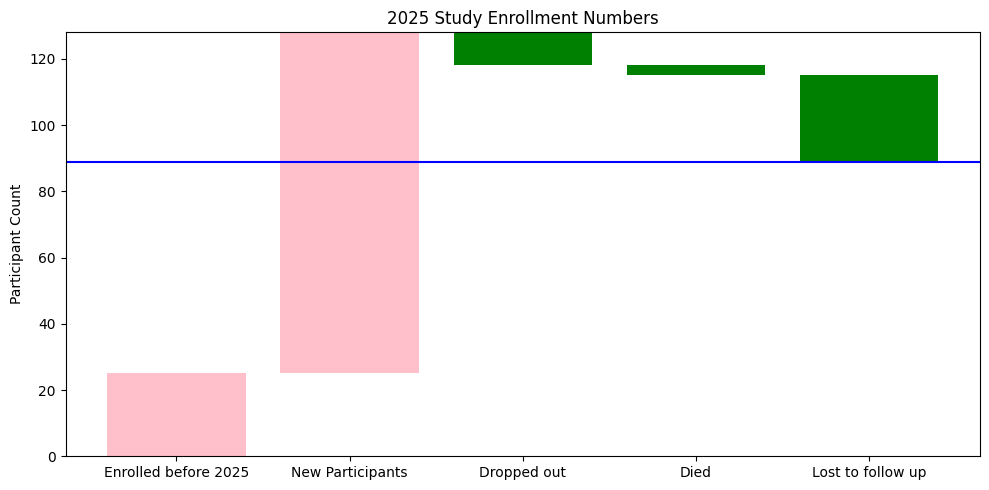

In [ ]:
import matplotlib.pyplot as plt

# I want to try a waterfall chart as I don't think I've ever seen them before!
# resource: https://www.domo.com/learn/charts/waterfall-charts

# I used to work in clinical research so I want to use study enrollment

# make a df
df_enrollment = pd.DataFrame({
    "2025 Participant Types":[
        "Enrolled before 2025",
        "New Participants",
        "Dropped out",
        "Died",
        "Lost to follow up"
    ],
    "Participant Counts":[
        25,
        103,
        -10,
        -3,
        -26
    ]
})

# make sure it looks right
# df_enrollment

# determine where the bars start and how tall they each are
df_enrollment["Cumulative_Enrollment"] = df_enrollment["Participant Counts"].cumsum()
# print(df_enrollment["Cumulative_Enrollment"])
df_enrollment["Previous_Enrollment"] = df_enrollment["Cumulative_Enrollment"] - df_enrollment["Participant Counts"]
# print(df_enrollment["Previous_Enrollment"])

# now let's start making our plots!!
plt.figure(figsize=(10,5))

# let's make a loop for the bars
for n in range(len(df_enrollment)):
    if df_enrollment.loc[n, "Participant Counts"] >= 0:
        color = "pink"
    else:
        color = "green"
    
    plt.bar(
        df_enrollment.loc[n, "2025 Participant Types"],
        df_enrollment.loc[n, "Participant Counts"],
        bottom = df_enrollment.loc[n, "Previous_Enrollment"],
        color = color
    )

#  now let's work on formatting!
final_enrollment = df_enrollment["Cumulative_Enrollment"].iloc[-1]
plt.axhline(final_enrollment, linestyle="solid", color ="blue")
plt.title("2025 Study Enrollment Numbers")
plt.ylabel("Participant Count")
plt.tight_layout()